<a href="https://colab.research.google.com/github/thenourjr/Deep-Learning/blob/main/CNN_LSTM_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Download Dataset**

In [ ]:
!wget -O "UCI_HAR_Dataset.zip" "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"

--2026-03-30 10:35:12--  https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘UCI_HAR_Dataset.zip’

UCI_HAR_Dataset.zip     [      <=>           ]  58.17M  37.7MB/s    in 1.5s    

2026-03-30 10:35:14 (37.7 MB/s) - ‘UCI_HAR_Dataset.zip’ saved [60999314]



### **Extract Dataset** **bold text**

In [ ]:
import zipfile
import os

zip_path = "/content/UCI_HAR_Dataset.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done.")
print(os.listdir("/content"))

Extraction done.
['.config', 'UCI_HAR_Dataset.zip', '__MACOSX', 'UCI HAR Dataset', 'sample_data']


### **Verify Dataset Structure**

In [ ]:
import os

dataset_path = "/content/UCI HAR Dataset"
print("Dataset exists:", os.path.exists(dataset_path))
print(os.listdir(dataset_path))

Dataset exists: True
['activity_labels.txt', '.DS_Store', 'README.txt', 'features_info.txt', 'train', 'test', 'features.txt']


### **Import Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

### **Load Dataset Functions**

In [ ]:
def load_file(filepath):
    return np.loadtxt(filepath)

def load_group(filenames, prefix=''):
    loaded = []
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    return np.dstack(loaded)

def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'

    filenames = [
        'total_acc_x_' + group + '.txt',
        'total_acc_y_' + group + '.txt',
        'total_acc_z_' + group + '.txt',
        'body_acc_x_' + group + '.txt',
        'body_acc_y_' + group + '.txt',
        'body_acc_z_' + group + '.txt',
        'body_gyro_x_' + group + '.txt',
        'body_gyro_y_' + group + '.txt',
        'body_gyro_z_' + group + '.txt'
    ]

    X = load_group(filenames, filepath)
    y = load_file(prefix + group + '/y_' + group + '.txt')
    return X, y

def load_dataset(prefix='/content/UCI HAR Dataset/'):
    trainX, trainy = load_dataset_group('train', prefix)
    testX, testy = load_dataset_group('test', prefix)

    trainy = trainy - 1
    testy = testy - 1

    trainy = to_categorical(trainy)
    testy = to_categorical(testy)

    return trainX, trainy, testX, testy

### **Load Dataset**



In [ ]:
trainX, trainy, testX, testy = load_dataset()

print("Train X shape:", trainX.shape)
print("Train y shape:", trainy.shape)
print("Test X shape:", testX.shape)
print("Test y shape:", testy.shape)

Train X shape: (7352, 128, 9)
Train y shape: (7352, 6)
Test X shape: (2947, 128, 9)
Test y shape: (2947, 6)


### **Data Visualization**

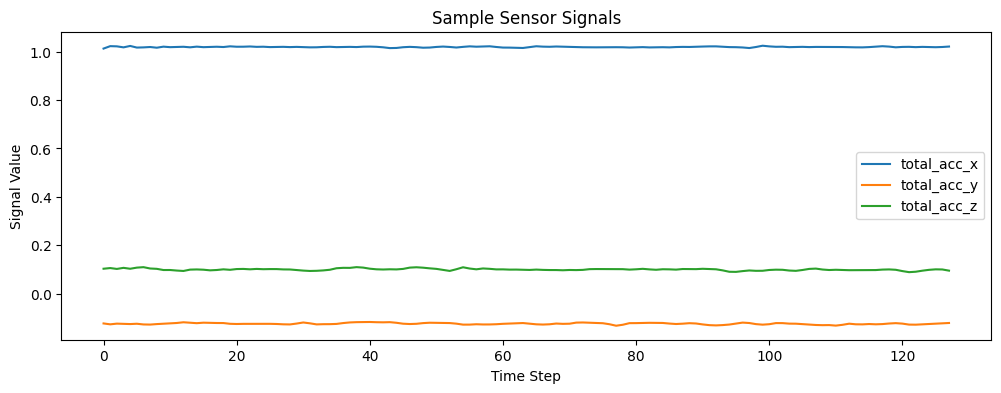

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(trainX[0, :, 0], label='total_acc_x')
plt.plot(trainX[0, :, 1], label='total_acc_y')
plt.plot(trainX[0, :, 2], label='total_acc_z')
plt.title("Sample Sensor Signals")
plt.xlabel("Time Step")
plt.ylabel("Signal Value")
plt.legend()
plt.show()

### **Define Activity Labels**

In [ ]:
labels = [
    'WALKING',
    'WALKING_UPSTAIRS',
    'WALKING_DOWNSTAIRS',
    'SITTING',
    'STANDING',
    'LAYING'
]

print(labels)

['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


### **Build CNN-LSTM Model**

In [ ]:
n_timesteps = trainX.shape[1]
n_features = trainX.shape[2]
n_outputs = trainy.shape[1]

model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_timesteps, n_features)),
    BatchNormalization(),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    BatchNormalization(),

    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    LSTM(100),
    Dropout(0.3),

    Dense(100, activation='relu'),
    Dense(n_outputs, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 124, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 124, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,362 (356.88 KB)

 Trainable params: 91,106 (355.88 KB)

 Non-trainable params: 256 (1.00 KB)

### **Train the Model**

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    trainX,
    trainy,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7875 - loss: 0.5838 - val_accuracy: 0.1808 - val_loss: 3.4235
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9349 - loss: 0.1585 - val_accuracy: 0.4765 - val_loss: 2.9580
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9478 - loss: 0.1202 - val_accuracy: 0.5914 - val_loss: 2.0500
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9572 - loss: 0.0981 - val_accuracy: 0.8029 - val_loss: 0.8147
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9541 - loss: 0.1051 - val_accuracy: 0.9082 - val_loss: 0.2685
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9531 - loss: 0.1001 - val_accuracy: 0.9055 - val_loss: 0.2888
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9604 - loss: 0.0885 - val_accuracy: 0.8987 - val_loss: 0.3438
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9594 - loss: 0.0850 - val_accuracy: 0.9143 - v

### **Evaluate the Model**

In [ ]:
loss, accuracy = model.evaluate(testX, testy, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.3717
Test Accuracy: 0.8979


### **Plot Accuracy**

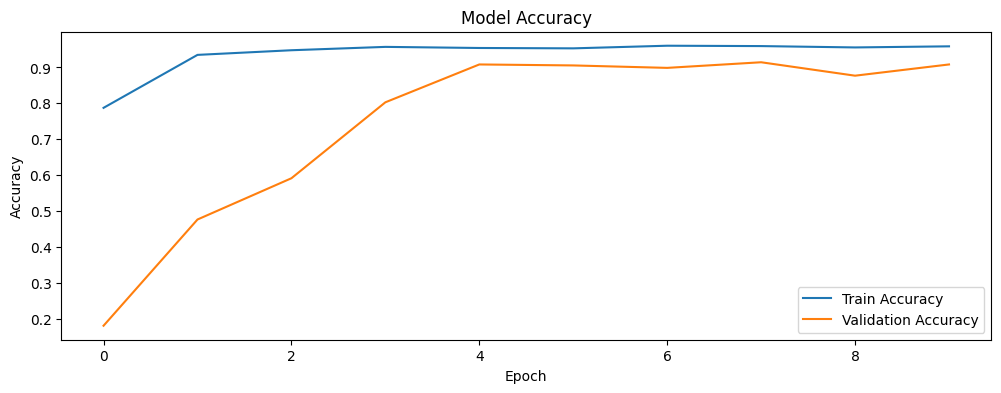

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### **Plot Loss**

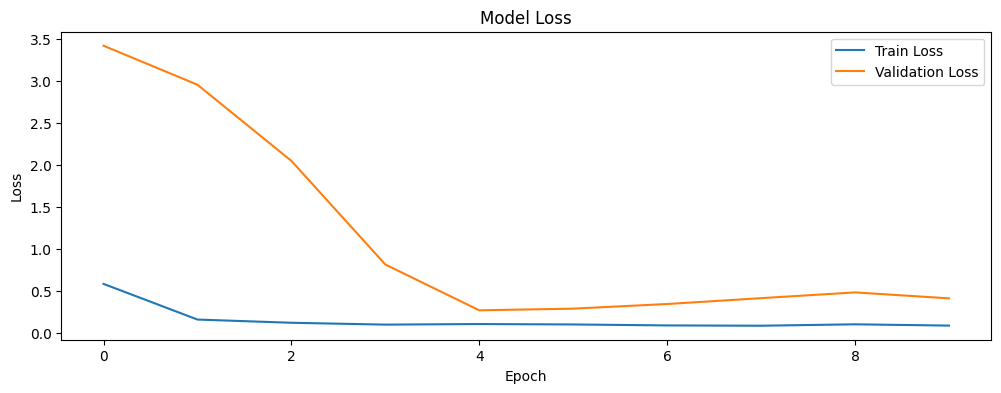

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### **Make Predictions**

In [ ]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(testy, axis=1)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


### **Classification Report**

In [ ]:
print(classification_report(y_true, y_pred_classes, target_names=labels))

                    precision    recall  f1-score   support

           WALKING       1.00      0.93      0.96       496
  WALKING_UPSTAIRS       0.80      0.97      0.87       471
WALKING_DOWNSTAIRS       0.96      0.90      0.93       420
           SITTING       0.82      0.80      0.81       491
          STANDING       0.85      0.85      0.85       532
            LAYING       0.99      0.95      0.97       537

          accuracy                           0.90      2947
         macro avg       0.90      0.90      0.90      2947
      weighted avg       0.90      0.90      0.90      2947



### **Confusion Matrix**

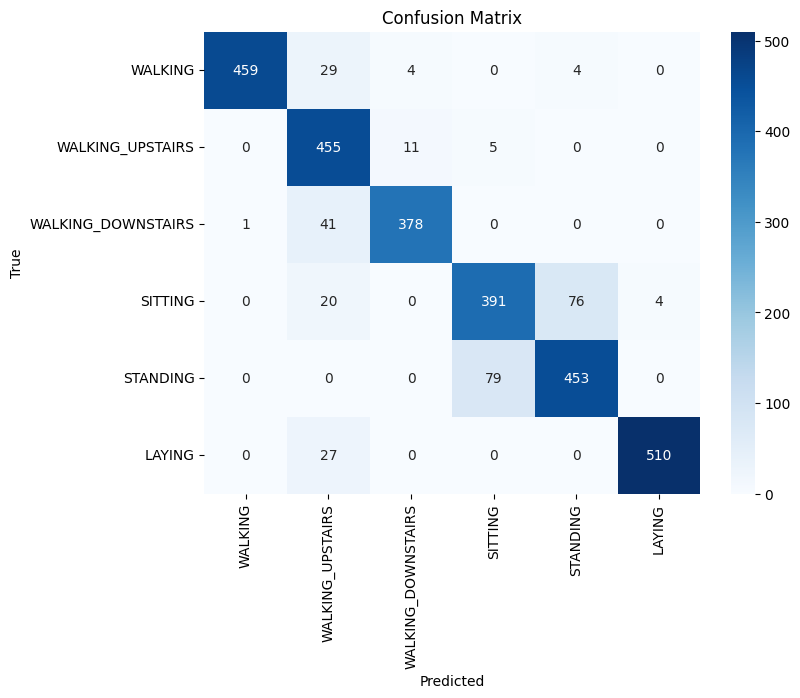

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

### **Save Model**

In [ ]:
model.save('/content/har_cnn_lstm_model.h5')
print("Model saved successfully.")

Model saved successfully.
